# Insurance Cost Analysis

A data analysis and machine learning project exploring the factors that influence annual medical insurance charges.

## Project Overview

This project applies a complete data science workflow to a medical insurance dataset, including:
- **Data loading & cleaning** — handling missing values and formatting
- **Exploratory Data Analysis (EDA)** — identifying key drivers of insurance cost
- **Model Development** — Linear Regression (single & multi-variable) and polynomial pipelines
- **Model Refinement** — Ridge Regression to improve generalization

## Dataset

| Feature | Description | Type |
|---|---|---|
| Age | Age in years | integer |
| Gender | Male (1) or Female (2) | integer |
| BMI | Body Mass Index | float |
| No_of_Children | Number of children | integer |
| Smoker | Smoker (1) or Non-smoker (0) | integer |
| Region | US region: NW(1), NE(2), SW(3), SE(4) | integer |
| Charges | Annual insurance charges (USD) | float |

**Source:** IBM Developer Skills Network / Coursera — Data Analysis with Python


## Setup

### Required Libraries

In [ ]:
# Uncomment to install if needed
# %pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

## 1. Load Dataset

In [ ]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'

# Load CSV (no headers in source file)
df = pd.read_csv(path, header=None)

# Assign column names
headers = ["Age", "Gender", "BMI", "No_of_Children", "Smoker", "Region", "Charges"]
df.columns = headers

print(df.head(10))

  Age  Gender     BMI  No_of_Children Smoker  Region      Charges
0  19       1  27.900               0      1       3  16884.92400
1  18       2  33.770               1      0       4   1725.55230
2  28       2  33.000               3      0       4   4449.46200
3  33       2  22.705               0      0       1  21984.47061
4  32       2  28.880               0      0       1   3866.85520
5  31       1  25.740               0      ?       4   3756.62160
6  46       1  33.440               1      0       4   8240.58960
7  37       1  27.740               3      0       1   7281.50560
8  37       2  29.830               2      0       2   6406.41070
9  60       1  25.840               0      0       1  28923.13692


## 2. Data Wrangling

### 2.1 Handle missing values

Replace `?` placeholders with `NaN`, then inspect missing data.

In [ ]:
df.replace("?", np.nan, inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             2768 non-null   object 
 1   Gender          2772 non-null   int64  
 2   BMI             2772 non-null   float64
 3   No_of_Children  2772 non-null   int64  
 4   Smoker          2765 non-null   object 
 5   Region          2772 non-null   int64  
 6   Charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB
None


### 2.2 Impute missing values

- **Continuous attributes** (Age, BMI): replace NaN with the column mean  
- **Categorical attributes** (Smoker): replace NaN with the most frequent value

In [ ]:
is_smoker = df['Smoker'].value_counts().idxmax()
df["Smoker"].replace(np.nan, is_smoker, inplace=True)

mean_age = df['Age'].astype('float').mean(axis=0)
df["Age"].replace(np.nan, mean_age, inplace=True)

df[["Age","Smoker"]] = df[["Age","Smoker"]].astype("int")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             2772 non-null   int32  
 1   Gender          2772 non-null   int64  
 2   BMI             2772 non-null   float64
 3   No_of_Children  2772 non-null   int64  
 4   Smoker          2772 non-null   int32  
 5   Region          2772 non-null   int64  
 6   Charges         2772 non-null   float64
dtypes: float64(2), int32(2), int64(3)
memory usage: 130.1 KB
None


### 2.3 Round charges to 2 decimal places

In [ ]:
df[["Charges"]] = np.round(df[["Charges"]],2)
print(df.head())

   Age  Gender     BMI  No_of_Children  Smoker  Region   Charges
0   19       1  27.900               0       1       3  16884.92
1   18       2  33.770               1       0       4   1725.55
2   28       2  33.000               3       0       4   4449.46
3   33       2  22.705               0       0       1  21984.47
4   32       2  28.880               0       0       1   3866.86


## 3. Exploratory Data Analysis (EDA)

### 3.1 BMI vs. Charges

Regression plot to visualize the relationship between BMI and insurance charges.

(0.0, 66902.85800000001)

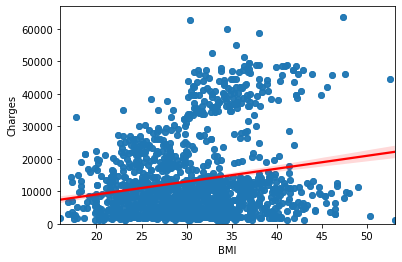

In [ ]:
sns.regplot(x="BMI", y="Charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)

### 3.2 Smoker status vs. Charges

Exploring whether smoking status is a strong predictor of insurance costs.

<AxesSubplot:xlabel='Smoker', ylabel='Charges'>

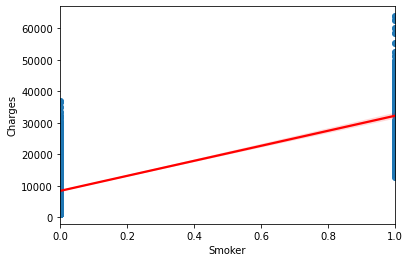

In [ ]:
sns.regplot(x="Smoker", y="Charges", data=df, line_kws={"color": "red"})

### 3.3 Correlation Matrix

Identifying which features are most correlated with `Charges`.

In [ ]:
print(df.corr())

                     Age    Gender       BMI  No_of_Children    Smoker  \
Age             1.000000 -0.026046  0.113048        0.037574 -0.023286   
Gender         -0.026046  1.000000  0.042924        0.016020  0.082326   
BMI             0.113048  0.042924  1.000000       -0.001492  0.011489   
No_of_Children  0.037574  0.016020 -0.001492        1.000000  0.006362   
Smoker         -0.023286  0.082326  0.011489        0.006362  1.000000   
Region         -0.007167  0.022213  0.271119       -0.025717  0.054077   
Charges         0.298624  0.062837  0.199846        0.066442  0.788783   

                  Region   Charges  
Age            -0.007167  0.298624  
Gender          0.022213  0.062837  
BMI             0.271119  0.199846  
No_of_Children -0.025717  0.066442  
Smoker          0.054077  0.788783  
Region          1.000000  0.054058  
Charges         0.054058  1.000000  


## 4. Model Development

### 4.1 Single-Variable Linear Regression

Using `Smoker` as the sole predictor (highest correlation with `Charges`).

In [ ]:
X = df[['Smoker']]
Y = df['Charges']
lm = LinearRegression()
lm.fit(X,Y)
print(lm.score(X, Y))

0.6221791733924185


### 4.2 Multi-Variable Linear Regression

Using all available features to predict charges.

In [ ]:
Z = df[["Age", "Gender", "BMI", "No_of_Children", "Smoker", "Region"]]
lm.fit(Z,Y)
print(lm.score(Z, Y))

0.7504083820289634


### 4.3 Polynomial Pipeline

Building a pipeline with `StandardScaler`, `PolynomialFeatures`, and `LinearRegression` to capture non-linear relationships.

In [ ]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]

pipe=Pipeline(Input)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
print(r2_score(Y,ypipe))

0.8452456286532801


## 5. Model Refinement

### 5.1 Train/Test Split

Splitting the data into 80% training and 20% testing subsets.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(Z,Y,test_size=0.2, random_state=1)

### 5.2 Ridge Regression

Applying Ridge regression (α = 0.1) to reduce overfitting.

In [ ]:
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))

0.6760807731582404


### 5.3 Ridge with Polynomial Features (degree=2)

Combining polynomial transformation with Ridge regularization for improved R² score.

In [ ]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.fit_transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.7835631107608153


## 6. Results Summary

| Model | R² Score |
|---|---|
| Linear Regression — Single Variable (Smoker) | ~0.622 |
| Linear Regression — Multi-Variable | ~0.750 |
| Polynomial Pipeline (degree=2) | ~0.845 |
| Ridge Regression (α=0.1) | ~0.676 |
| Ridge + Polynomial Features (degree=2) | ~0.784 |

**Key findings:**
- `Smoker` is the single most predictive feature for insurance charges.
- A polynomial pipeline captures non-linear relationships and achieves the best R² (~0.845).
- Ridge regression improves generalization on unseen data compared to standard linear regression.
